## Выбор данных для домашнего задания
Ссылка на датасет: [Зарплата, образование, страна, тип занятости](https://www.kaggle.com/datasets/nalisha/job-salary-prediction-dataset/data)

**Описание данных**
* `job_title`: Название позиции
* `experience_years`: Количество лет опыта работы
* `education_level`: Уровень образования
* `skills_count`: Количество навыков
* `industry`: Сфера деятельности
* `company_size`: Размер компании
* `location`: Регион
* `remote_work`: Тип занятости
* `certifications`:	Количество сертификатов
* `salary`:	Годовая зарплата

In [395]:
#импортирую библиотеки
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [396]:
df = pd.read_csv('job_salary_prediction_dataset.csv')

### Предобработка данных

1. Смотрю начало и конец датасета

In [397]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [398]:
df.tail()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,127791
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,154593
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467
249999,Data Analyst,16,Diploma,2,Technology,Medium,UK,No,5,133084


In [399]:
df.columns

Index(['job_title', 'experience_years', 'education_level', 'skills_count',
       'industry', 'company_size', 'location', 'remote_work', 'certifications',
       'salary'],
      dtype='object')

2. Изучаю, какие типы данных представлены. Бегло проверяю, есть ли пропуски.

   Все данные, которые должны быть imt, действительно являются числовыми.

In [400]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


Посмотрю, есть ли дубликаты

In [401]:
df.duplicated().sum()

np.int64(0)

**Перевожу тип object в тип string**

In [402]:
df['job_title'].astype(str)
df['education_level'].astype(str)
df['industry'].astype(str)
df['company_size'].astype(str)
df['location'].astype(str)
df['remote_work'].astype(str)

0         Hybrid
1             No
2             No
3            Yes
4            Yes
           ...  
249995        No
249996        No
249997       Yes
249998    Hybrid
249999        No
Name: remote_work, Length: 250000, dtype: object

**Для объектов типа str проверю уникальные значения на случай ошибок ввода.**

In [403]:
df['job_title'].unique()

array(['AI Engineer', 'Data Analyst', 'Frontend Developer',
       'Business Analyst', 'Product Manager', 'Backend Developer',
       'Machine Learning Engineer', 'DevOps Engineer',
       'Software Engineer', 'Cybersecurity Analyst', 'Data Scientist',
       'Cloud Engineer'], dtype=object)

In [404]:
df['education_level'].unique()

array(['Bachelor', 'PhD', 'High School', 'Diploma', 'Master'],
      dtype=object)

In [405]:
df['industry'].unique()

array(['Healthcare', 'Telecom', 'Media', 'Retail', 'Manufacturing',
       'Education', 'Finance', 'Technology', 'Consulting', 'Government'],
      dtype=object)

In [406]:
df['company_size'].unique()

array(['Medium', 'Small', 'Large', 'Enterprise', 'Startup'], dtype=object)

In [407]:
df['location'].unique()

array(['India', 'Australia', 'Singapore', 'Canada', 'Sweden', 'USA',
       'Netherlands', 'Remote', 'Germany', 'UK'], dtype=object)

Значения `Renmote` будут оставлены в датасете, так как не планируется анализ по странам.

In [408]:
df['remote_work'].unique()

array(['Hybrid', 'No', 'Yes'], dtype=object)

Исследую пропущенные значения (их нет - Ура!)

In [409]:
df.isnull().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

**Ниже столбец образования будет приведен к выбору Да\Нет для высшего образования в отдельной колонке**

In [410]:
higher_education = ['Bachelor', 'PhD', 'Diploma', 'Master']

df['higher_education'] = df['education_level'].apply(
    lambda x: 'Yes' if x in higher_education else 'No'
)

**`Enterprise`, `Startup` будут `Large` и `Small` соответственно для размера компании.**

In [411]:
df_filtered_company_size = df.replace('Startup', 'Small')
df_filtered_company_size = df_filtered_company_size.replace('Enterprise', 'Large')

df_filtered_company_size['company_size'].value_counts()

company_size
Large     100129
Small      99844
Medium     50027
Name: count, dtype: int64

In [412]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary,higher_education
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413,Yes
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764,Yes
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123,Yes
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123,Yes
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069,Yes


## Проанализирую числовые и нечисловые данные



Выделю отдельно для удобства числовые переменные

In [413]:
numeric_vars = ['experience_years', 'skills_count', 'certifications', 'salary']

In [414]:
df[numeric_vars].describe().round(2)

,experience_years,skills_count,certifications,salary
count,250000.00,250000.00,250000.00,250000.00
mean,10.01,10.00,2.49,145718.08
std,6.06,5.48,1.71,37407.95
min,0.00,1.00,0.00,31867.00
25%,5.00,5.00,1.00,119358.00
50%,10.00,10.00,2.00,143453.00
75%,15.00,15.00,4.00,169492.00
max,20.00,19.00,5.00,333046.00


Среднее арифметическое и стандартное отклонение уже представлены выше. Медиана также соответствует 50% квантилю.
Посмотрю моду и медиану для числовых переменных.

In [415]:
df[numeric_vars].mode().iloc[0]

experience_years        14
skills_count            14
certifications           0
salary              140468
Name: 0, dtype: int64

### Для всех числовых переменных проведу тесты на нормальность
- гистограмма распределения
- ящик с усами
- нормально-вероятностный график (QQ plot)
- анализ асимметрии
- анализ эксцессов
- критерий Колмогорова-Смирнова

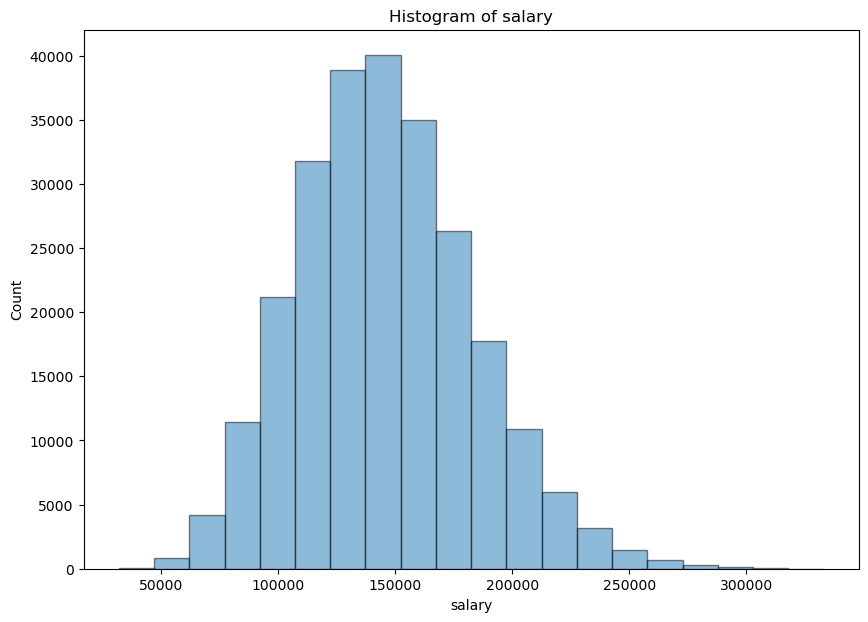

In [416]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.hist(df['salary'], edgecolor='black', bins=20, alpha=.5)

ax.set_title('Histogram of salary')
ax.set_xlabel('salary')
ax.set_ylabel('Count');

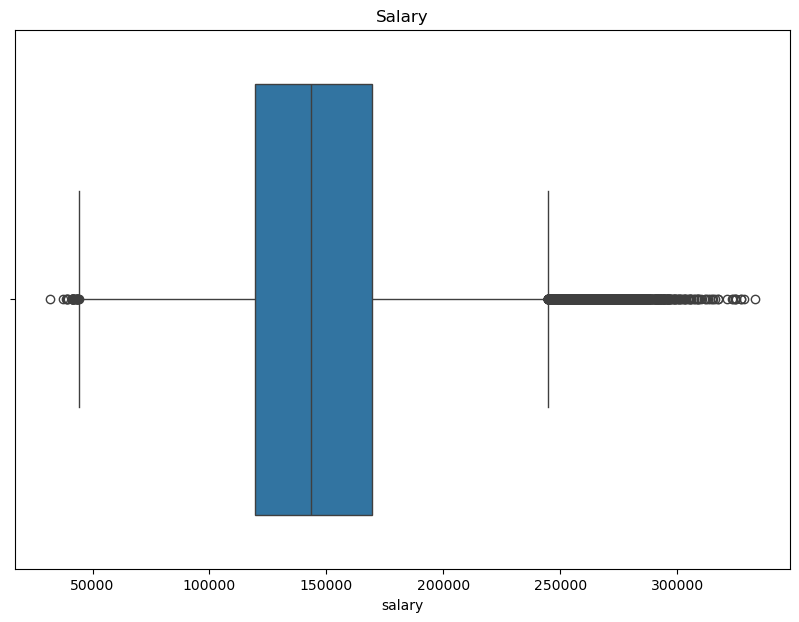

In [417]:
fig, ax = plt.subplots(figsize=(10, 7))

sns.boxplot(x='salary', data=df, ax=ax)

ax.set_title('Salary');

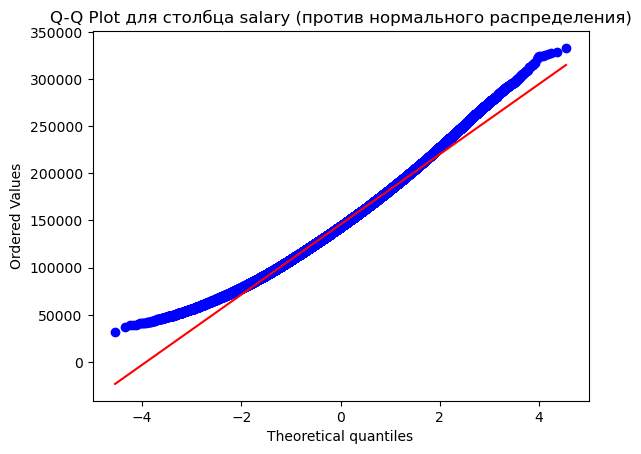

In [418]:
import scipy.stats as stats

stats.probplot(df['salary'], dist="norm", plot=plt)
plt.title('Q-Q Plot для столбца salary (против нормального распределения)')
plt.show()

In [419]:
skewness_salary = df['salary'].skew()
len_df = len(df['salary'])
std_skewness_salary = ((6*len_df*(len_df-1))/((len_df-2)*(len_df+1)*(len_df+3)))**(1/2)
print(f'Коэф. асимметрии: {skewness_salary}')
print(f'Стандартное отклонение коэф. асимметрии: {std_skewness_salary}')
print(f'Разделим стандартное отклонение на коэф. асимметрии: {std_skewness_salary/skewness_salary}')

Коэф. асимметрии: 0.3794009747285934
Стандартное отклонение коэф. асимметрии: 0.004898950092032369
Разделим стандартное отклонение на коэф. асимметрии: 0.012912328692715826


Для нормального распределения отношение должно быть больше 3.

In [420]:
kurt_salary = df['salary'].kurtosis()
std_kurt_salary = ((4*((len_df**2) - 1)*(std_skewness_salary**2))/((len_df-3)*(len_df+5)))**(1/2)

print(f'Коэф. эксцесса: {kurt_salary}')
print(f'Стандартное отклонение коэф. эксцесса: {std_kurt_salary}')
print(f'Разделим стандартное отклонение на коэф. эксцесса: {std_kurt_salary/kurt_salary}')

Коэф. эксцесса: 0.15089558099594536
Стандартное отклонение коэф. эксцесса: 0.0097978609937965
Разделим стандартное отклонение на коэф. эксцесса: 0.06493139778599463


Для нормального распределения отношение должно быть больше 3.

In [421]:
kstest_salary = stats.kstest(df['salary'], 'norm')
kstest_salary

KstestResult(statistic=np.float64(1.0), pvalue=np.float64(0.0), statistic_location=np.int64(31867), statistic_sign=np.int8(-1))

p-value меньше 0.05, распределение отличается от нормального

#### Вывод: `salary` распределено ненормально.

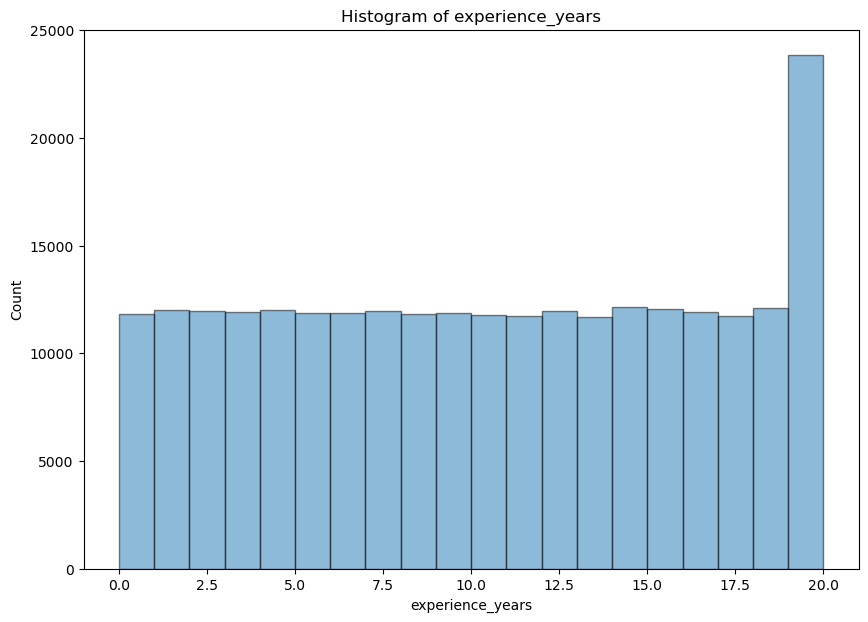

In [422]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.hist(df['experience_years'], edgecolor='black', bins=20, alpha=.5)

ax.set_title('Histogram of experience_years')
ax.set_xlabel('experience_years')
ax.set_ylabel('Count');

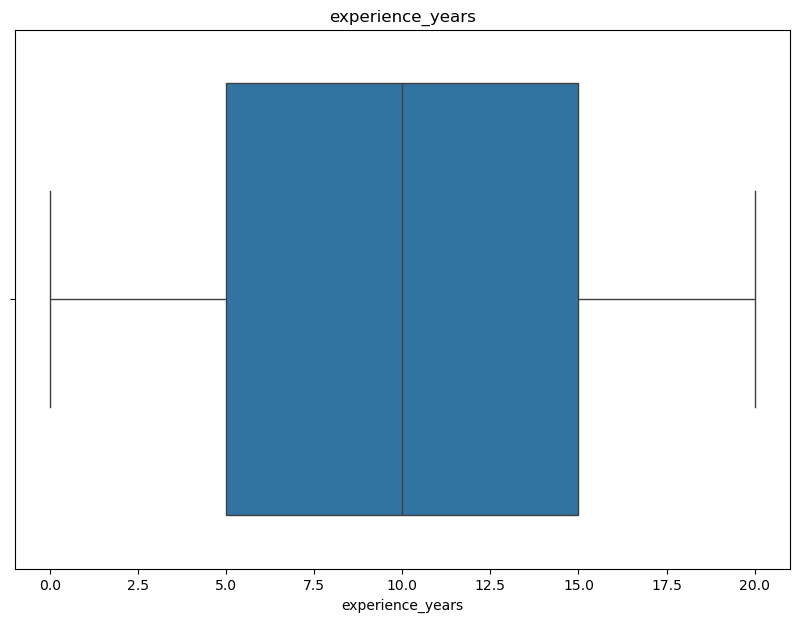

In [423]:
fig, ax = plt.subplots(figsize=(10, 7))

sns.boxplot(x='experience_years', data=df, ax=ax)

ax.set_title('experience_years');

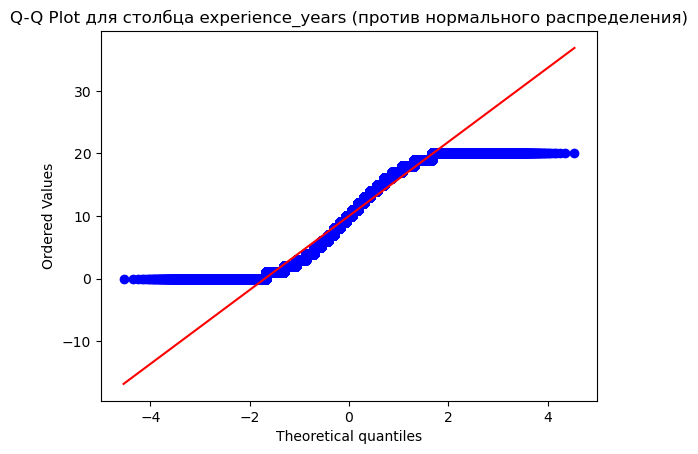

In [424]:
stats.probplot(df['experience_years'], dist="norm", plot=plt)
plt.title('Q-Q Plot для столбца experience_years (против нормального распределения)')
plt.show()

In [425]:
skewness_experience_years = df['experience_years'].skew()
std_skewness_experience_years = ((6*len_df*(len_df-1))/((len_df-2)*(len_df+1)*(len_df+3)))**(1/2)
print(f'Коэф. асимметрии: {skewness_experience_years}')
print(f'Стандартное отклонение коэф. асимметрии: {std_skewness_experience_years}')
print(f'Разделим стандартное отклонение на коэф. асимметрии: {std_skewness_salary/skewness_experience_years}')

Коэф. асимметрии: -0.0009517323628733434
Стандартное отклонение коэф. асимметрии: 0.004898950092032369
Разделим стандартное отклонение на коэф. асимметрии: -5.1474030758417335


Для нормального распределения отношение должно быть больше 3.

In [426]:
kurt_experience_years = df['experience_years'].kurtosis()
std_kurt_experience_years = ((4*((len_df**2) - 1)*(std_skewness_experience_years**2))/((len_df-3)*(len_df+5)))**(1/2)

print(f'Коэф. эксцесса: {kurt_experience_years}')
print(f'Стандартное отклонение коэф. эксцесса: {std_kurt_experience_years}')
print(f'Разделим стандартное отклонение на коэф. эксцесса: {std_kurt_experience_years/kurt_experience_years}')

Коэф. эксцесса: -1.209296861873609
Стандартное отклонение коэф. эксцесса: 0.0097978609937965
Разделим стандартное отклонение на коэф. эксцесса: -0.008102113966140875


Для нормального распределения отношение должно быть больше 3.

In [427]:
kstest_experience_years = stats.kstest(df['experience_years'], 'norm')
kstest_experience_years

KstestResult(statistic=np.float64(0.8819898680518208), pvalue=np.float64(0.0), statistic_location=np.int64(2), statistic_sign=np.int8(-1))

p-value меньше 0.05, распределение отличается от нормального

#### Вывод: `experience_years` распределено ненормально.

**Так как остальные числовые данные не интересны в разрезе нормальности / ненормальности распределения, для них построю только гистограммы**

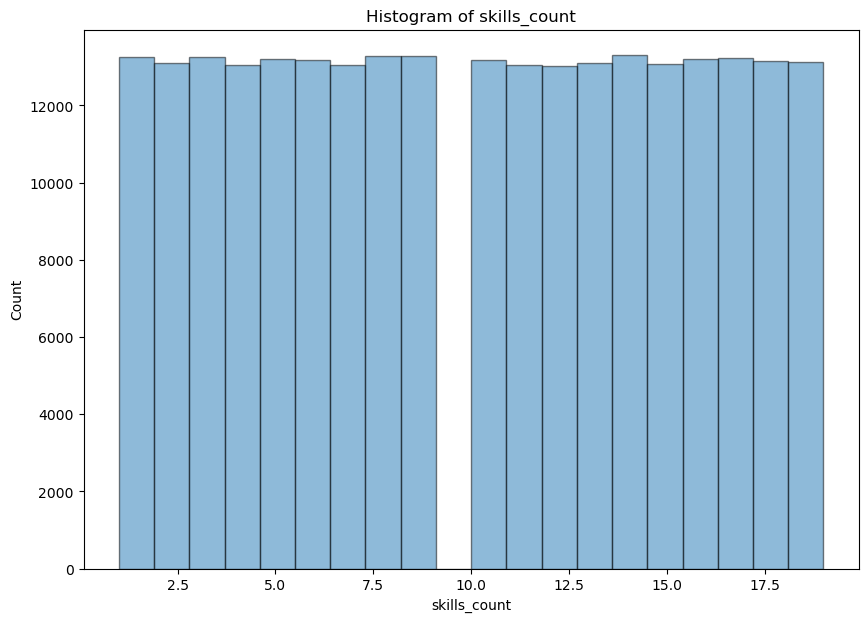

In [428]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.hist(df['skills_count'], edgecolor='black', bins=20, alpha=.5)

ax.set_title('Histogram of skills_count')
ax.set_xlabel('skills_count')
ax.set_ylabel('Count');

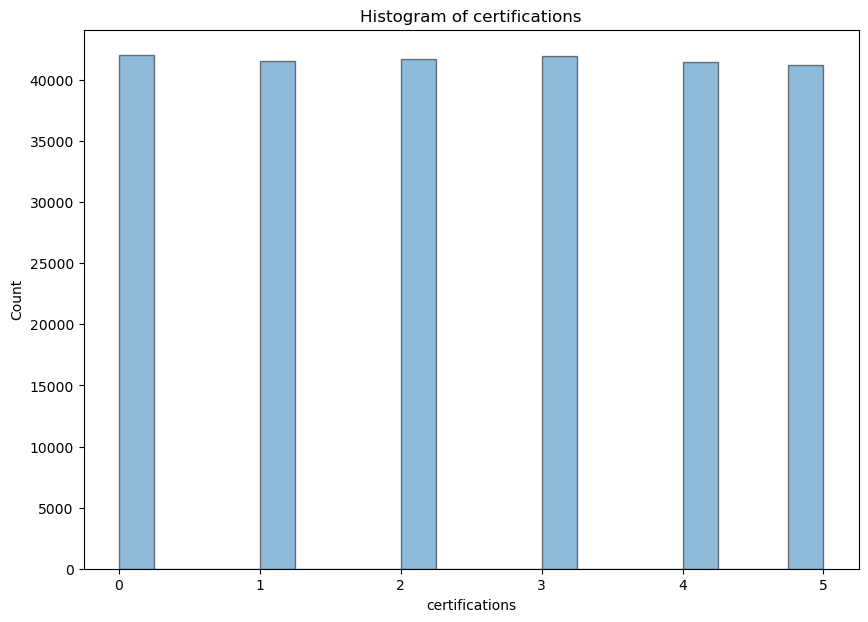

In [429]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.hist(df['certifications'], edgecolor='black', bins=20, alpha=.5)

ax.set_title('Histogram of certifications')
ax.set_xlabel('certifications')
ax.set_ylabel('Count');

## Рассмотрю категориальные переменные. Визуализация не нужна.

In [430]:
df.describe(include=['O'])

,job_title,education_level,industry,company_size,location,remote_work,higher_education
count,250000,250000,250000,250000,250000,250000,250000
unique,12,5,10,5,10,3,2
top,Backend Developer,Master,Finance,Large,Australia,No,Yes
freq,21125,50352,25393,50254,25258,83621,199935


In [431]:
df['job_title'].value_counts()

job_title
Backend Developer            21125
Cybersecurity Analyst        20959
Product Manager              20950
AI Engineer                  20945
Data Scientist               20890
DevOps Engineer              20889
Software Engineer            20876
Data Analyst                 20722
Cloud Engineer               20686
Machine Learning Engineer    20677
Business Analyst             20648
Frontend Developer           20633
Name: count, dtype: int64

In [432]:
df['education_level'].value_counts()

education_level
Master         50352
High School    50065
Bachelor       49950
PhD            49857
Diploma        49776
Name: count, dtype: int64

In [433]:
df['industry'].value_counts()

industry
Finance          25393
Consulting       25258
Media            25034
Manufacturing    25024
Technology       24903
Government       24901
Healthcare       24898
Education        24889
Telecom          24859
Retail           24841
Name: count, dtype: int64

In [434]:
df['company_size'].value_counts()

company_size
Large         50254
Small         50235
Medium        50027
Enterprise    49875
Startup       49609
Name: count, dtype: int64

In [435]:
df['location'].value_counts()

location
Australia      25258
Canada         25165
Sweden         25100
Remote         25065
Singapore      25035
USA            24931
UK             24927
India          24895
Netherlands    24861
Germany        24763
Name: count, dtype: int64

# Изучение взаимодействия между переменными.

## Влияет ли опыт на зарплату?

Это числовые переменные. Распределение ненормальное, поэтому нельзя использовать корреляцию Пирсона. Будем использовать корреляцию Спирмена и Кендала.

In [436]:
stats.spearmanr(df['experience_years'].values, df['salary'].values)

SignificanceResult(statistic=np.float64(0.43789083653740235), pvalue=np.float64(0.0))

In [437]:
stats.kendalltau(df['experience_years'].values, df['salary'].values)

SignificanceResult(statistic=np.float64(0.30604418932381366), pvalue=np.float64(0.0))

По результатам: статистически значимая (p-value меньше 0.05) умеренная положительная связь.

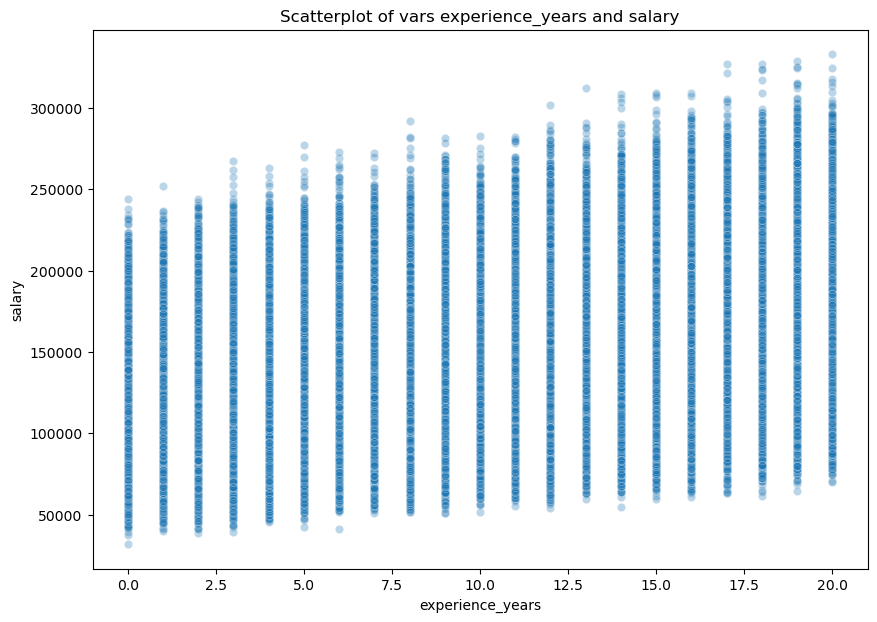

In [438]:
fig, ax = plt.subplots(figsize=(10, 7))

sns.scatterplot(x='experience_years', y='salary', ax=ax, data=df, alpha=0.3)

ax.set_title(f'Scatterplot of vars experience_years and salary')
ax.set_xlabel('experience_years')
ax.set_ylabel('salary');

Попробую построить другим образом (виолончели)

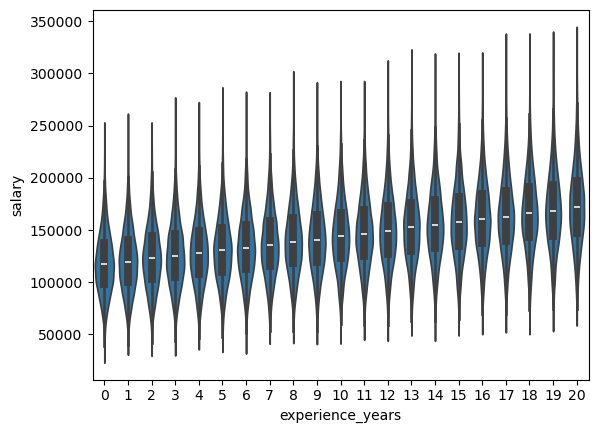

In [439]:
sns.violinplot(x='experience_years', y='salary', data=df)
plt.show()

Так как слишком мало значений для данных типа `experience_years`, я буду считать эти данные категориальными, проведу группировку и проанализирую по среднему.

In [440]:
df_experience_as_categorical = df.copy()
df_experience_as_categorical['experience_years'] = df['experience_years'].astype('category')
df_experience_as_categorical_grouped = df_experience_as_categorical.groupby('experience_years', observed=True)['salary'].agg('mean') #добавила observed=True после предупреждения
df_experience_as_categorical_grouped

experience_years
0     118872.622755
1     121250.527183
2     124228.943849
3     126921.603112
4     129688.783435
5     131787.250717
6     134898.296712
7     137560.810366
8     140667.762731
9     142763.834683
10    145771.972998
11    148133.173236
12    150779.033238
13    154082.616121
14    156413.152885
15    158981.141636
16    162290.866980
17    164282.181423
18    167421.185837
19    169797.362442
20    173179.709650
Name: salary, dtype: float64

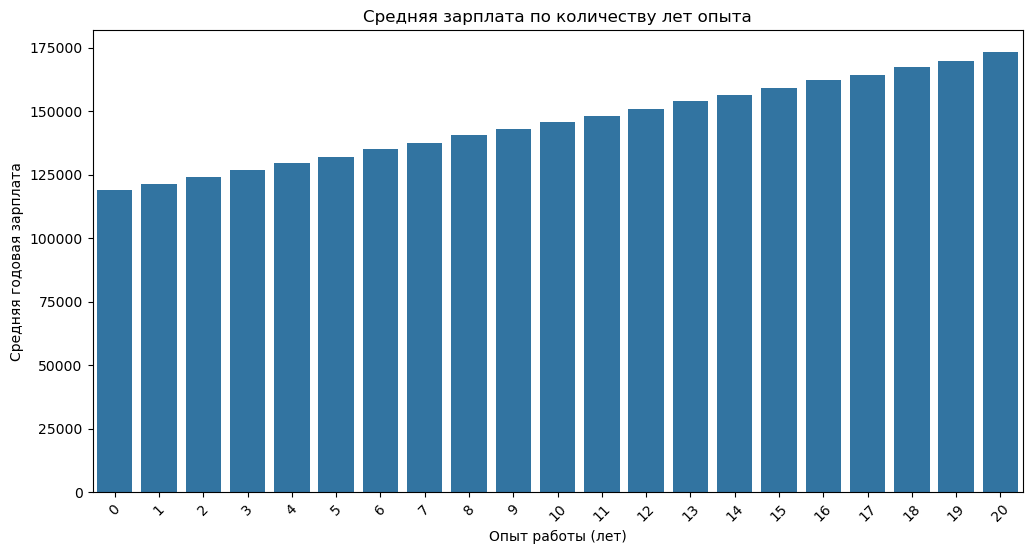

In [441]:
plt.figure(figsize=(12, 6))
sns.barplot(x=df_experience_as_categorical_grouped.index,
             y=df_experience_as_categorical_grouped.values)
plt.title('Средняя зарплата по количеству лет опыта')
plt.xlabel('Опыт работы (лет)')
plt.ylabel('Средняя годовая зарплата')
plt.xticks(rotation=45)
plt.show()

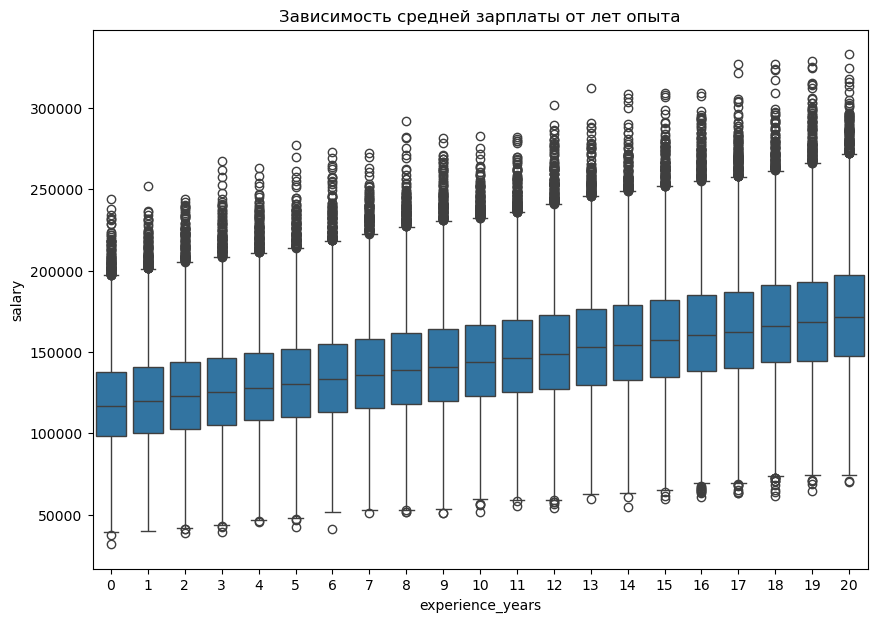

In [442]:
fig, ax = plt.subplots(figsize=(10, 7))

sns.boxplot(x='experience_years', y='salary', data=df_experience_as_categorical, ax=ax)

ax.set_title('Зависимость средней зарплаты от лет опыта');

**В общем видно, что есть слабовыраженная зависимость зарплаты от лет опыта, но данные слишком "искуственные".**

## Рассмотрим, зависит ли профессия на уровень зарплаты.

Это связь между категориальной переменной и числовой.

In [443]:
df.groupby(['job_title'])['salary'].agg(['mean', 'median', 'std']).round(2)

,mean,median,std
job_title,,,
AI Engineer,173498.48,171674.0,38093.17
Backend Developer,139202.77,136678.0,33198.87
Business Analyst,122551.23,120562.0,31346.36
Cloud Engineer,152102.54,150005.0,35120.10
Cybersecurity Analyst,148697.70,146737.0,34525.31
Data Analyst,119891.70,118079.5,30734.84
Data Scientist,147258.21,145231.5,34227.02
DevOps Engineer,149959.27,148021.0,34455.58
Frontend Developer,132653.84,130619.0,32358.07


Так как категорий много, выберу визуализацию boxplot

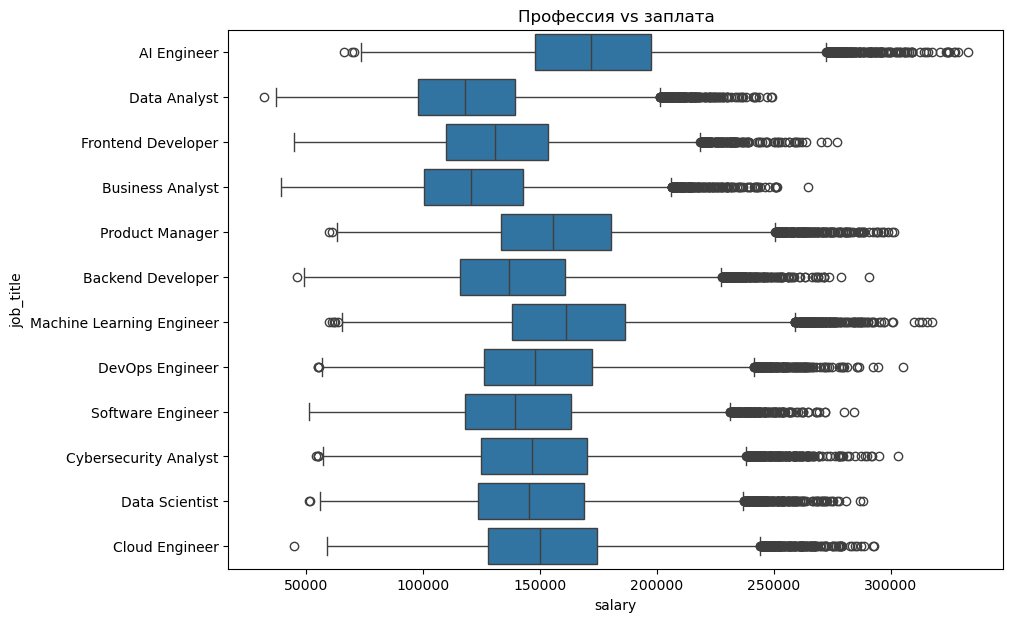

In [444]:
fig, ax = plt.subplots(figsize=(10, 7))

sns.boxplot(x='salary', y='job_title', data=df, ax=ax)

ax.set_title('Профессия vs заплата');

Так как я хочу увидеть связь между категориальной и ненормально распределенной числовой переменными, использую тест Краскела-Уоллиса.

In [445]:
groups = [group['salary'].values for name, group in df.groupby('job_title')]
groups

[array([109413, 180351, 171834, ..., 156565, 161163, 246720],
       shape=(20945,)),
 array([165375, 119988, 115823, ...,  99765, 100077, 149227],
       shape=(21125,)),
 array([189123, 157417, 106481, ..., 103724, 171896,  75988],
       shape=(20648,)),
 array([162923, 152413, 155886, ..., 110229, 157100, 159104],
       shape=(20686,)),
 array([161268, 125030, 168253, ..., 140780, 206954, 134112],
       shape=(20959,)),
 array([ 93764,  87600,  96611, ...,  87314,  94870, 133084],
       shape=(20722,)),
 array([109478, 111158, 168153, ..., 122021, 177929,  90467],
       shape=(20890,)),
 array([155931, 151828, 141409, ..., 173822, 169844, 215279],
       shape=(20889,)),
 array([148123, 128377, 105755, ..., 111896, 193028, 154593],
       shape=(20633,)),
 array([202463, 191757, 213920, ..., 144028, 129118, 185049],
       shape=(20677,)),
 array([165069, 154190, 141207, ...,  79311, 212857, 191137],
       shape=(20950,)),
 array([124532, 115827, 121570, ..., 194674, 100592, 1

In [446]:
stats.kruskal(*groups)

KruskalResult(statistic=np.float64(39682.43864144709), pvalue=np.float64(0.0))

Так как pvalue меньше 0.05, различия между зарплатами по категориям значимо отличаются. Можно сказать, что AI Engineer зарабатывает в среднем больше в сравнении с другими профессиями. 

## Влияет ли размер компании на тип занятости (удаленка/офис)?

Это связь двух категориальных переменных, поэтому для анализа будет использован Хи-квадрат.

In [447]:
#таблица сопряженности
contingency_table = pd.crosstab(df['company_size'], df['remote_work'])
contingency_table

remote_work,Hybrid,No,Yes
company_size,,,
Enterprise,16574,16590,16711
Large,16756,16907,16591
Medium,16794,16743,16490
Small,16734,16797,16704
Startup,16618,16584,16407


In [448]:
#хи квадрат
chi_size_remote = stats.chi2_contingency(contingency_table)
chi_size_remote

Chi2ContingencyResult(statistic=np.float64(5.207617782892701), pvalue=np.float64(0.7351726940316721), dof=8, expected_freq=array([[16653.462   , 16682.3895  , 16539.1485  ],
       [16780.011616, 16809.158936, 16664.829448],
       [16704.215408, 16733.231068, 16589.553524],
       [16773.66744 , 16802.80374 , 16658.52882 ],
       [16564.643536, 16593.416756, 16450.939708]]))

**pvalue сильно больше 0.05, поэтому нулевая гипотеза об отсутствии связи не отклоняется**

Все равно посмотрим визуализацию))

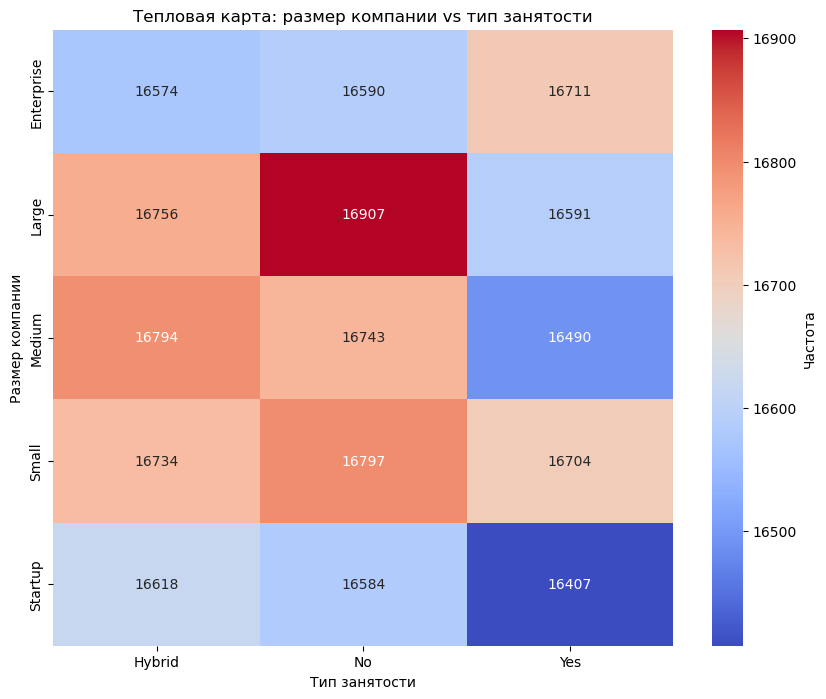

In [449]:
plt.figure(figsize=(10, 8))
sns.heatmap(contingency_table, annot=True, fmt="d", cmap="coolwarm", cbar_kws={"label": "Частота"})
plt.title("Тепловая карта: размер компании vs тип занятости")
plt.xlabel("Тип занятости")
plt.ylabel("Размер компании")
plt.show()

## Влияет ли уровень образования на зарплату?
В данном случае столбец `higher_education` можно считать ординальной переменной, которая все-таки ближе к категориальной.
Для сравнения этой переменной с числовой переменной (`salary`) хочу использовать Т-критерий Стьюдента или U-критерий Манна-Уитни. Критерий выбирается на основании того, нормально ли распределены значения в подгруппах.

In [450]:
df_stats_edu = df.groupby('higher_education')['salary'].agg([
    'count', 'mean', 'std', 'min', 'max', 'median'
]).round(2)
summary_stats_edu

,count,mean,std,min,max,median
higher_education,,,,,,
No,50065,131715.34,33601.79,31867,287961,129663.0
Yes,199935,149224.46,37491.94,41276,333046,147088.0


In [451]:
df_edu =  df.groupby('higher_education')['salary']

In [452]:
edu_yes = df_edu.get_group('Yes')
edu_no = df_edu.get_group('No')

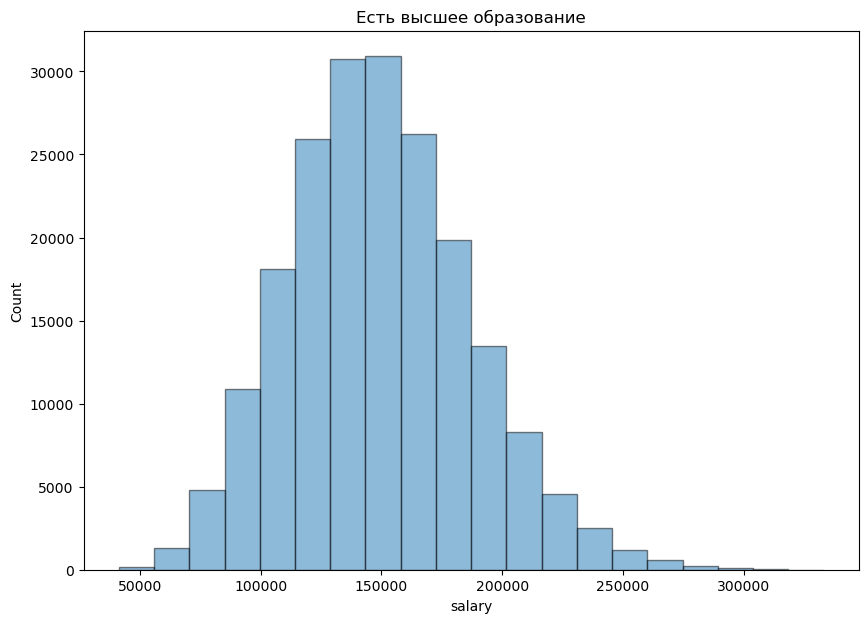

In [453]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.hist(edu_yes, edgecolor='black', bins=20, alpha=.5)

ax.set_title('Есть высшее образование')
ax.set_xlabel('salary')
ax.set_ylabel('Count');

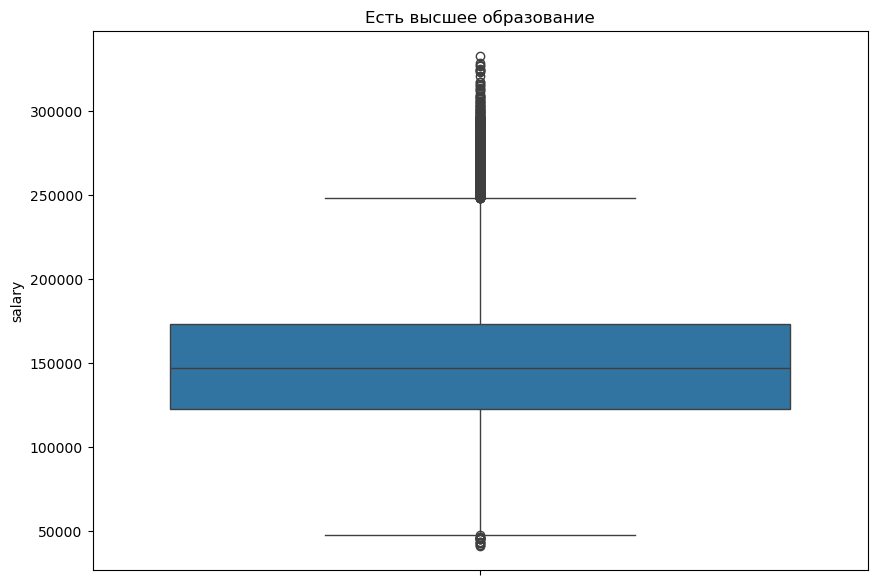

In [454]:
fig, ax = plt.subplots(figsize=(10, 7))

sns.boxplot(y=edu_yes)

ax.set_title('Есть высшее образование');

Уже видно, что данные распределены ненормально. Поэтому будем использовать U-критерий Манна-Уитни.

In [455]:
mannwhitneyu_edu = stats.mannwhitneyu(edu_yes, edu_no, alternative='two-sided')
mannwhitneyu_edu

MannwhitneyuResult(statistic=np.float64(6356386987.5), pvalue=np.float64(0.0))

pvalue меньше 0.05 - отклоняем нулевую гипотезу о том, что выборки одинаковы. Есть статистически значимая разница в зарплате между теми, у кого есть и нет высшего образования.
Наглядно можно посмотреть на boxplot ниже.

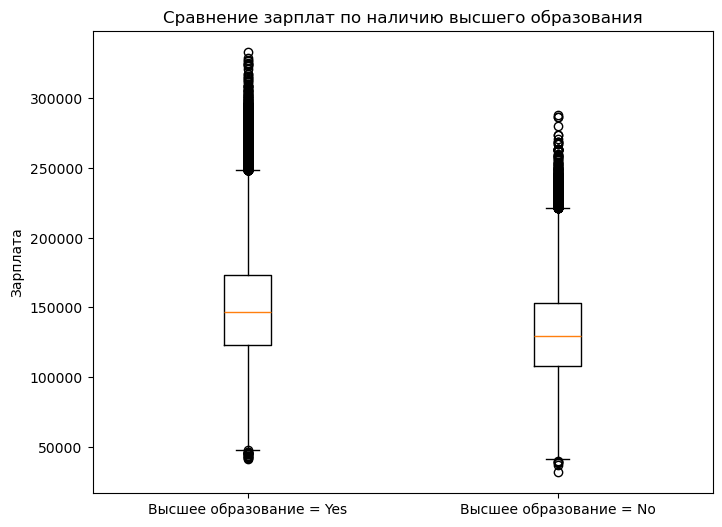

In [456]:
plt.figure(figsize=(8, 6))
plt.boxplot([edu_yes, edu_no], tick_labels=['Высшее образование = Yes', 'Высшее образование = No'])
plt.title('Сравнение зарплат по наличию высшего образования')
plt.ylabel('Зарплата')

plt.show()

## Общий вывод о данных можно сделать такой: искуственные данные, не наблюдается сильных взаимосвязей, которые ожидаются интуитивно между переменными.